In [18]:
! pip install scanpy leidenalg --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 77.2 MB/s eta 0:00:00


In [2]:
import scanpy as sc

In [4]:
# load dataset
url = "https://raw.githubusercontent.com/rikaaaac/comp-bio-erc-workshop/main/pbmc_10k.h5ad"
! wget -q -O /tmp/pbmc_10k.h5ad "{url}"
adata = sc.read_h5ad("/tmp/pbmc_10k.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 9506 × 38606
    var: 'gene_ids', 'feature_types', 'genome'


## Pre-processing
Filtering out genes and cells, normalization, and logarithmization

In [8]:
# filter out low quality genes and cells

# filter out cells that have < 100 genes
sc.pp.filter_cells(adata, min_genes=100)
# filter out genes that are expressed in less than 3 cells
sc.pp.filter_genes(adata, min_cells=3)

In [12]:
adata

AnnData object with n_obs × n_vars = 9471 × 25215
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'

In [13]:
# normalize and logarithmize data
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

## Dimension Reduction

In [15]:
sc.tl.pca(adata, n_comps=30)

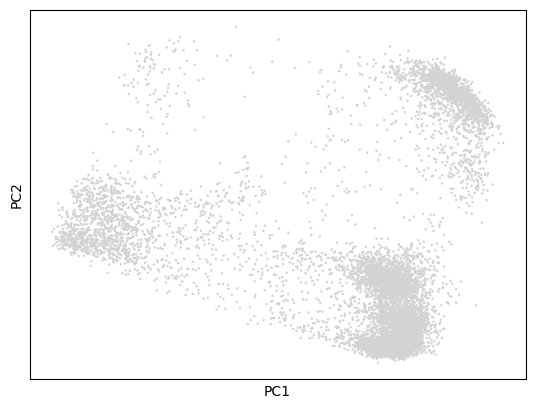

In [16]:
sc.pl.pca(adata)

## Clustering

In [20]:
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.leiden(adata)

/tmp/ipykernel_6332/609525186.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


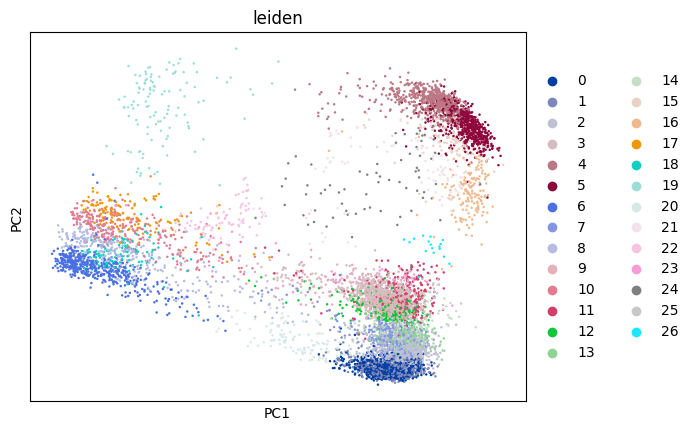

In [21]:
sc.pl.pca(adata, color='leiden')

## Visualization

In [26]:
adata.var_names.tolist()

['ENSG00000238009',
 'ENSG00000241860',
 'ENSG00000290385',
 'ENSG00000291215',
 'LINC01409',
 'ENSG00000290784',
 'FAM87B',
 'LINC00115',
 'LINC01128',
 'ENSG00000288531',
 'FAM41C',
 'ENSG00000272438',
 'ENSG00000230699',
 'NOC2L',
 'KLHL17',
 'PLEKHN1',
 'ENSG00000272512',
 'HES4',
 'ISG15',
 'ENSG00000224969',
 'AGRN',
 'ENSG00000291156',
 'C1orf159',
 'ENSG00000285812',
 'LINC01342',
 'TTLL10',
 'TNFRSF18',
 'TNFRSF4',
 'SDF4',
 'B3GALT6',
 'C1QTNF12',
 'ENSG00000260179',
 'UBE2J2',
 'LINC01786',
 'SCNN1D',
 'ACAP3',
 'PUSL1',
 'INTS11',
 'ENSG00000240731',
 'CPTP',
 'TAS1R3',
 'DVL1',
 'MXRA8',
 'AURKAIP1',
 'CCNL2',
 'MRPL20-AS1',
 'MRPL20',
 'MRPL20-DT',
 'ANKRD65',
 'VWA1',
 'ATAD3C',
 'ATAD3B',
 'ENSG00000290916',
 'ATAD3A',
 'TMEM240',
 'SSU72',
 'ENSG00000215014',
 'FNDC10',
 'ENSG00000286989',
 'ENSG00000272106',
 'MIB2',
 'MMP23B',
 'CDK11B',
 'ENSG00000272004',
 'SLC35E2B',
 'CDK11A',
 'ENSG00000290854',
 'NADK',
 'GNB1',
 'GNB1-DT',
 'CALML6',
 'TMEM52',
 'CFAP74',
 'PR

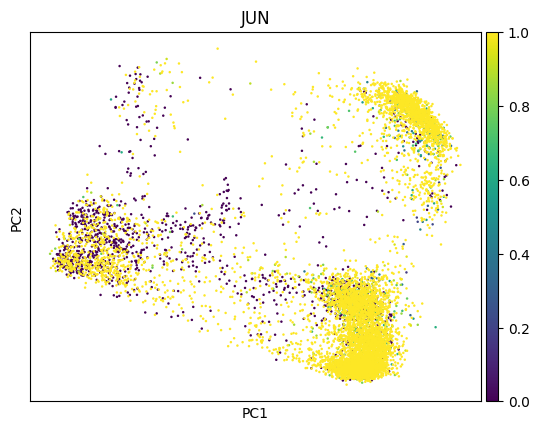

In [36]:
sc.pl.pca(adata, color='JUN', vmax=1)